Case Use: Predicting the Impact of Environmental Variables on Fish Migration Patterns
Problem Description:
Marine ecologists aim to understand how various environmental variables influence fish migration patterns. Specifically, they want to model the dependency of fish migration distances on factors such as water temperature, salinity, and ocean currents.

Statistical Technique:
Multiple Regression will be used to build a predictive model that relates multiple independent variables (environmental factors) to a dependent variable (fish migration distance).

Hypothesis:
The hypothesis is that water temperature, salinity, and ocean current speed are significant predictors of the distance that fish migrate seasonally.

Dataset Description:
The dataset includes observations from 200 tagged fish, with the following variables:

Water Temperature (degrees Celsius)
Salinity (PSU)
Ocean Current Speed (km/h)
Migration Distance (km)
Student Task:
The student is tasked with using the provided multiple regression code to build a predictive model for fish migration distances. They are required to:

Interpret the significance of each predictor in the model.
Adjust the model to include interaction terms if hypothesized that interactions between variables may be significant.
Validate the assumptions of multiple regression, including checking for multicollinearity and heteroscedasticity.

                            OLS Regression Results                            
Dep. Variable:     Migration Distance   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     208.5
Date:                Mon, 20 May 2024   Prob (F-statistic):           1.01e-60
Time:                        05:20:58   Log-Likelihood:                -744.75
No. Observations:                 200   AIC:                             1498.
Df Residuals:                     196   BIC:                             1511.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.5064      8.225     -0.548

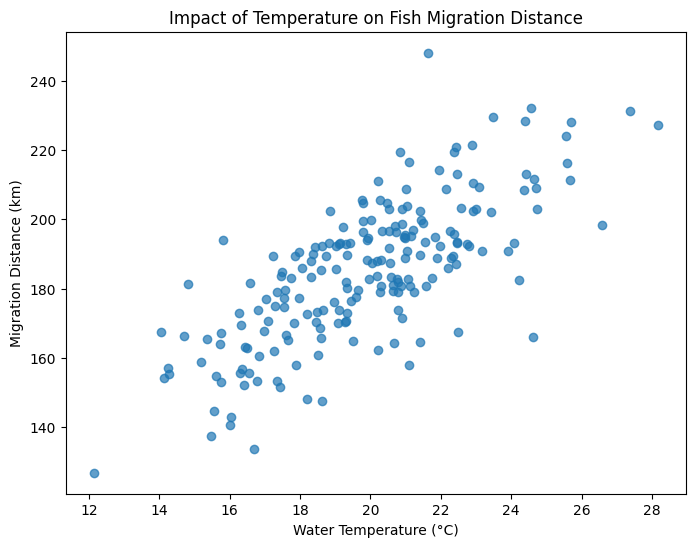

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
data_size = 200
temperature = np.random.normal(20, 3, data_size)  # Water temperature
salinity = np.random.normal(35, 5, data_size)     # Salinity
current_speed = np.random.normal(5, 1, data_size) # Ocean current speed
migration_distance = (5 * temperature + 2 * salinity + 3 * current_speed + np.random.normal(0, 10, data_size))

# Create a DataFrame
data = pd.DataFrame({
    'Temperature': temperature,
    'Salinity': salinity,
    'Current Speed': current_speed,
    'Migration Distance': migration_distance
})

# Multiple Regression Model
X = data[['Temperature', 'Salinity', 'Current Speed']]
X = sm.add_constant(X)  # Adding a constant term for the intercept
y = data['Migration Distance']

model = sm.OLS(y, X).fit()

# Display the regression results
print(model.summary())

# Plotting temperature vs. migration to visualize potential relationships
plt.figure(figsize=(8, 6))
plt.scatter(data['Temperature'], y, alpha=0.7)
plt.title('Impact of Temperature on Fish Migration Distance')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Migration Distance (km)')
plt.show()


Instructions for Students:
Run the provided code to understand the initial regression results.
Experiment with adding quadratic terms for temperature and current speed to test for non-linear effects.
Check the residuals of the model to assess whether they meet the assumptions of normality and constant variance.
Interpret the coefficients and their p-values to assess which environmental factors are significant predictors of migration distance.
This case use allows students to practically apply multiple regression to a realistic scenario in marine ecology, fostering deeper understanding of statistical modeling and environmental science.

Según los resultador iniciales obtenidos

Temperatura del Agua: Por cada aumento de un grado Celsius en la temperatura del agua, la distancia de migración de los peces aumenta aproximadamente 5.33 km (valor p < 0.001).

Salinidad: Por cada aumento de una unidad PSU en la salinidad, la distancia de migración de los peces aumenta aproximadamente 1.78 km (valor p < 0.001).

Velocidad de la Corriente Oceánica: Por cada aumento de 1 km/h en la velocidad de la corriente oceánica, la distancia de migración de los peces aumenta aproximadamente 4.18 km (valor p < 0.001).

El valor de R-cuadrado de 0.761 indica que el 76.1% de la variación en la distancia de migración de los peces puede ser explicada por las variables independientes.



In [ ]:
# Add quadratic terms
X['Temperature_Squared'] = X['Temperature'] ** 2
X['Current Speed_Squared'] = X['Current Speed'] ** 2

X = sm.add_constant(X)

model_quadratic = sm.OLS(y, X).fit()
print(model_quadratic.summary())

                            OLS Regression Results                            
Dep. Variable:     Migration Distance   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     124.0
Date:                Mon, 20 May 2024   Prob (F-statistic):           1.86e-58
Time:                        05:21:17   Log-Likelihood:                -744.62
No. Observations:                 200   AIC:                             1501.
Df Residuals:                     194   BIC:                             1521.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   -17.40

Para revisar los supuestos sobre los residuos del modelo, hacemos un Q-Q Plot
Para los supestos de normalidad y homocedasticidad de varianzas


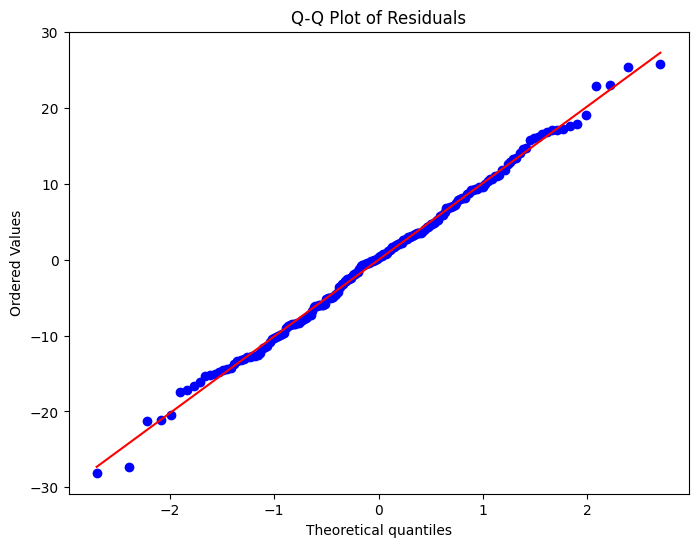

In [ ]:
import scipy.stats as stats

# Calculate residuals
residuals = model_quadratic.resid

# Create Q-Q plot
fig, ax = plt.subplots(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=ax)
plt.title("Q-Q Plot of Residuals")
plt.show()

En este caso se observa que si se cumplen los supuestos de homocedasticidad de varianzas y normalidad dde los residuoes del modelo, ya que se ajustan a la diagonal del Q-Q plot.

Además, el modelo cuadratico explica:

Temperatura: Por cada grado Celsius de aumento en la temperatura, la distancia de migración de los peces aumenta en aproximadamente 6.15 km (p-valor = 0.023).

Salinidad: Por cada unidad de aumento en la salinidad, la distancia de migración de los peces aumenta en aproximadamente 1.77 km (p-valor < 0.001).

Velocidad del corriente: Por cada km/h de aumento en la velocidad del corriente, la distancia de migración de los peces aumenta en aproximadamente 6.25 km (p-valor = 0.251). Sin embargo, el término cuadrático de la velocidad del corriente no es estadísticamente significativo (p-valor = 0.701), lo que sugiere que no hay un efecto no lineal en la relación entre la velocidad del corriente y la distancia de migración de los peces.

Términos cuadráticos: El término cuadrático de la temperatura no es estadísticamente significativo (p-valor = 0.763), lo que sugiere que no hay un efecto no lineal en la relación entre la temperatura y la distancia de migración de los peces.

El coeficiente de determinación ajustado (R-cuadrado ajustado) es de 0.756, lo que indica que el modelo explica el 75.6% de la variabilidad en la distancia de migración de los peces.
